In [17]:
import os
print(f"Available CPUs: {os.cpu_count()}")

Available CPUs: 8


# 1. Install Necessary Libraries

We install `gspread` and `scikit-learn` as before, and add `gensim` for Doc2Vec support.

In [18]:
!pip install --upgrade -q gspread scikit-learn pandas gensim seaborn

# 2. Authenticate and Access Google Drive + Sheets

In [19]:
# Google Sheets Linking (Needs user authorization)
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

gc = gspread.authorize(creds)

# 3. Import Datasets

We import all dataset splits:

**DBTL1 Splits (from prior iteration):**
- Raw — Train/Validate, Evaluation
- Group1 Preprocessed — Train/Validate, Evaluation
- Group2 Preprocessed — Train/Validate, Evaluation

**DBTL2 Split (new):**
- DBTL2 Preprocessed — Train/Validate (single training set), Evaluation at 3 thresholds: `eval_50`, `eval_5`, `eval_1`

In [20]:
import pandas as pd

# Raw_Eval
wb_raw_eval = gc.open_by_url('https://docs.google.com/spreadsheets/d/1KsidfWCrywomIAbdlNg6Gn5rMER9E8gpI2AxGpNfjZ4/edit?usp=drive_link')
data_raw_eval = wb_raw_eval.get_worksheet(0).get_all_values()
df_raw_eval = pd.DataFrame(data_raw_eval[1:], columns=data_raw_eval[0])

# Raw_TrainValid
wb_raw_tv = gc.open_by_url('https://docs.google.com/spreadsheets/d/1swxApDpgutQxNKr6GJHSr96PQZUxd_qcKAx8hlV7YOI/edit?usp=drive_link')
data_raw_tv = wb_raw_tv.get_worksheet(0).get_all_values()
df_raw_train_valid = pd.DataFrame(data_raw_tv[1:], columns=data_raw_tv[0])

In [21]:
# Group1_Preprocessed_Eval
wb_g1_eval = gc.open_by_url('https://docs.google.com/spreadsheets/d/1-7gT9ZaJbaG35HpCWQqJyhFo1Vl4AfQ-HeLLSWLlhdA/edit?usp=drive_link')
data_g1_eval = wb_g1_eval.get_worksheet(0).get_all_values()
df_g1_preprocessed_eval = pd.DataFrame(data_g1_eval[1:], columns=data_g1_eval[0])

# Group1_Preprocessed_TrainValid
wb_g1_tv = gc.open_by_url('https://docs.google.com/spreadsheets/d/1py--oeZRWbSVVBqrsLe0WZXRqhfaS_ZcNYqHIiLOcvM/edit?usp=drive_link')
data_g1_tv = wb_g1_tv.get_worksheet(0).get_all_values()
df_g1_preprocessed_train_valid = pd.DataFrame(data_g1_tv[1:], columns=data_g1_tv[0])

In [22]:
# Group2_Preprocessed_Eval
wb_g2_eval = gc.open_by_url('https://docs.google.com/spreadsheets/d/1j3pF9gIkk_FiLEjT6STIxELDWC1EDm8Qxur849n-VFw/edit?usp=drive_link')
data_g2_eval = wb_g2_eval.get_worksheet(0).get_all_values()
df_g2_preprocessed_eval = pd.DataFrame(data_g2_eval[1:], columns=data_g2_eval[0])

# Group2_Preprocessed_TrainValid
wb_g2_tv = gc.open_by_url('https://docs.google.com/spreadsheets/d/1-rdT3VXb-0fi3kP96KVL4TWRwXG-sAPWeGcilLk_fTA/edit?usp=drive_link')
data_g2_tv = wb_g2_tv.get_worksheet(0).get_all_values()
df_g2_preprocessed_train_valid = pd.DataFrame(data_g2_tv[1:], columns=data_g2_tv[0])

In [23]:
# -------------------------------------------------------------------
# DBTL2 Datasets (NEW)
# Three separate evaluation sets at different thresholds (50, 5, 1),
# all trained against a single shared TrainValid split.
# -------------------------------------------------------------------

# DBTL2_Preprocessed_Eval (Multiple)
wb_dblt2_eval_50 = gc.open_by_url('https://docs.google.com/spreadsheets/d/1VwDnWLw9gLDfvNhVl1z4pIaEy7s0_MEStWZo9nuYKD4/edit?usp=drive_link')
data_dblt2_eval_50 = wb_dblt2_eval_50.get_worksheet(0).get_all_values()
df_dblt2_preprocessed_eval_50 = pd.DataFrame(data_dblt2_eval_50[1:], columns=data_dblt2_eval_50[0])

wb_dblt2_eval_5 = gc.open_by_url('https://docs.google.com/spreadsheets/d/1XfD7MHfxCC-C1QncX2tEQ-TnDSwEL97GyTaKMdD0I0w/edit?usp=drive_link')
data_dblt2_eval_5 = wb_dblt2_eval_5.get_worksheet(0).get_all_values()
df_dblt2_preprocessed_eval_5 = pd.DataFrame(data_dblt2_eval_5[1:], columns=data_dblt2_eval_5[0])

wb_dblt2_eval_1 = gc.open_by_url('https://docs.google.com/spreadsheets/d/1W13mNJYEzwJlHVUiJ5ux28kvFf-hbOLyKtFn676sCx8/edit?usp=drive_link')
data_dblt2_eval_1 = wb_dblt2_eval_1.get_worksheet(0).get_all_values()
df_dblt2_preprocessed_eval_1 = pd.DataFrame(data_dblt2_eval_1[1:], columns=data_dblt2_eval_1[0])

# DBTL2_Preprocessed_TrainValid
wb_dblt2_tv = gc.open_by_url('https://docs.google.com/spreadsheets/d/1w8dP9OOaHrcc1LyZfE-k7Cn9wN60m0EiFZPD6jOG9GE/edit?usp=drive_link')
data_dblt2_tv = wb_dblt2_tv.get_worksheet(0).get_all_values()
df_dblt2_preprocessed_train_valid = pd.DataFrame(data_dblt2_tv[1:], columns=data_dblt2_tv[0])

print(f"DBTL2 Train/Valid: {len(df_dblt2_preprocessed_train_valid)} rows")
print(f"DBTL2 Eval (50): {len(df_dblt2_preprocessed_eval_50)} rows")
print(f"DBTL2 Eval (5):  {len(df_dblt2_preprocessed_eval_5)} rows")
print(f"DBTL2 Eval (1):  {len(df_dblt2_preprocessed_eval_1)} rows")

DBTL2 Train/Valid: 3200 rows
DBTL2 Eval (50): 800 rows
DBTL2 Eval (5):  421 rows
DBTL2 Eval (1):  404 rows


# 4. Doc2Vec Embedding

**Why Doc2Vec instead of N-Gram + TF-IDF?**

TF-IDF treats each word independently and ignores word order and semantics. **Doc2Vec** (Paragraph Vector), introduced by Le & Mikolov (2014), learns a dense, fixed-size vector representation for entire documents by training a shallow neural network to predict words given their context *and* a document-level tag. This means:

- Word order and local context are captured (unlike bag-of-words / TF-IDF)
- The resulting embeddings are **dense** (300-dimensional), removing the need for dimensionality reduction (TruncatedSVD) before tree/distance-based models
- Semantically similar documents will have similar vectors

**Training process:**

1. Each document in the training corpus is tagged with a unique integer ID
2. A `Doc2Vec` model (PV-DM architecture by default) is trained on those `TaggedDocument` objects
3. After training, `model.infer_vector(tokens)` produces a vector for any new document (including test-set documents) without re-training

**Key hyperparameters:**

| Parameter | Value | Description |
|---|---|---|
| `vector_size` | 300 | Dimensionality of the embedding (matches prior SVD output dim) |
| `min_count` | 2 | Ignore words that appear fewer than 2 times |
| `epochs` | 40 | Number of training passes over the corpus |
| `workers` | 4 | Parallel threads |
| `dm` | 1 | Use PV-DM (Distributed Memory) architecture |

In [24]:
import numpy as np
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from gensim.utils import simple_preprocess

# ---------- Helper Functions ----------

def tokenize_series(text_series):
    """Lowercases and tokenizes a pandas Series of strings."""
    return [simple_preprocess(str(doc)) for doc in text_series]


def train_doc2vec(train_texts, vector_size=300, min_count=2, epochs=40):
    """
    Trains a Doc2Vec model on the given list of tokenized documents.
    Returns the trained model.
    """
    tagged_docs = [
        TaggedDocument(words=tokens, tags=[i])
        for i, tokens in enumerate(train_texts)
    ]
    model = Doc2Vec(
        vector_size=vector_size,
        min_count=min_count,
        epochs=epochs,
        workers=4,
        dm=1,          # PV-DM architecture
        seed=42
    )
    model.build_vocab(tagged_docs)
    model.train(tagged_docs, total_examples=model.corpus_count, epochs=model.epochs)
    return model


def infer_vectors(model, tokenized_docs):
    """
    Uses a trained Doc2Vec model to infer document vectors for a list
    of tokenized documents.
    Returns a numpy array of shape (n_docs, vector_size).
    """
    return np.array([model.infer_vector(tokens) for tokens in tokenized_docs])

In [25]:
# ---------------------------------------------------------------
# Train one Doc2Vec model per dataset's training corpus, then
# infer dense vectors for the training/validation set.
# ---------------------------------------------------------------

# --- Raw ---
print("Training Doc2Vec on Raw corpus...")
raw_train_tokens = tokenize_series(df_raw_train_valid['text'])
doc2vec_raw = train_doc2vec(raw_train_tokens)
X_raw_train_valid = infer_vectors(doc2vec_raw, raw_train_tokens)
print(f"  Raw embeddings shape: {X_raw_train_valid.shape}")

# --- Group1 ---
print("Training Doc2Vec on Group1 corpus...")
g1_train_tokens = tokenize_series(df_g1_preprocessed_train_valid['text'])
doc2vec_g1 = train_doc2vec(g1_train_tokens)
X_g1_train_valid = infer_vectors(doc2vec_g1, g1_train_tokens)
print(f"  Group1 embeddings shape: {X_g1_train_valid.shape}")

# --- Group2 ---
print("Training Doc2Vec on Group2 corpus...")
g2_train_tokens = tokenize_series(df_g2_preprocessed_train_valid['text'])
doc2vec_g2 = train_doc2vec(g2_train_tokens)
X_g2_train_valid = infer_vectors(doc2vec_g2, g2_train_tokens)
print(f"  Group2 embeddings shape: {X_g2_train_valid.shape}")

# --- DBTL2 (NEW) ---
print("Training Doc2Vec on DBTL2 corpus...")
dblt2_train_tokens = tokenize_series(df_dblt2_preprocessed_train_valid['text'])
doc2vec_dblt2 = train_doc2vec(dblt2_train_tokens)
X_dblt2_train_valid = infer_vectors(doc2vec_dblt2, dblt2_train_tokens)
print(f"  DBTL2 embeddings shape: {X_dblt2_train_valid.shape}")

print("\nAll Doc2Vec models trained successfully!")

Training Doc2Vec on Raw corpus...
  Raw embeddings shape: (3200, 300)
Training Doc2Vec on Group1 corpus...
  Group1 embeddings shape: (3200, 300)
Training Doc2Vec on Group2 corpus...
  Group2 embeddings shape: (3200, 300)
Training Doc2Vec on DBTL2 corpus...
  DBTL2 embeddings shape: (3200, 300)

All Doc2Vec models trained successfully!


# 5. Label Encoding (Labels into Numerical)

We encode the target labels for all four dataset splits:

1. **`label_generic`** → Binary: `phishing = 1`, `legit = 0`
2. **`label_specific`** → Multi-class: integer-encoded via `LabelEncoder`

In [26]:
from sklearn.preprocessing import LabelEncoder

# --- Encoding for Raw_TrainValid ---
le_raw = LabelEncoder()
y_raw_specific = le_raw.fit_transform(df_raw_train_valid['label_specific'])
y_raw_generic = df_raw_train_valid['label_generic'].apply(lambda x: 1 if x == 'phishing' else 0)

# --- Encoding for Group1_Preprocessed_TrainValid ---
le_g1 = LabelEncoder()
y_g1_specific = le_g1.fit_transform(df_g1_preprocessed_train_valid['label_specific'])
y_g1_generic = df_g1_preprocessed_train_valid['label_generic'].apply(lambda x: 1 if x == 'phishing' else 0)

# --- Encoding for Group2_Preprocessed_TrainValid ---
le_g2 = LabelEncoder()
y_g2_specific = le_g2.fit_transform(df_g2_preprocessed_train_valid['label_specific'])
y_g2_generic = df_g2_preprocessed_train_valid['label_generic'].apply(lambda x: 1 if x == 'phishing' else 0)

# --- Encoding for DBTL2_Preprocessed_TrainValid (NEW) ---
le_dblt2 = LabelEncoder()
y_dblt2_specific = le_dblt2.fit_transform(df_dblt2_preprocessed_train_valid['label_specific'])
y_dblt2_generic = df_dblt2_preprocessed_train_valid['label_generic'].apply(lambda x: 1 if x == 'phishing' else 0)

print("Label encoding complete.")
print(f"  DBTL2 specific classes: {le_dblt2.classes_}")

Label encoding complete.
  DBTL2 specific classes: ['human_legit' 'human_phishing' 'llm_legit' 'llm_phishing']


# 6. Train (and Validate / Tune)

**Stratified 10-Fold**: Ensures that each fold preserves the same class distribution as the full dataset, which is critical when classes are imbalanced.

**GridSearchCV**: Exhaustively searches over a grid of hyperparameters and picks the configuration that maximises the refit metric.

**Note on model changes from DBTL1:**
- Because Doc2Vec already produces **dense** 300-dimensional vectors, the `Pipeline + TruncatedSVD` wrappers used in DBTL1 for KNN, Random Forest, AdaBoost, and XGBoost are no longer needed. All models receive a plain dense numpy array.
- `MultinomialNB` required non-negative features (TF-IDF counts). Doc2Vec embeddings can contain negative values, so we replace it with **`GaussianNB`**, which models feature distributions as Gaussians and handles any real-valued input.

**Models:**
```
Logistic Regression
Gaussian Naive Bayes
Linear SVM
KNN
Random Forest
AdaBoost
XGBoost
```

In [27]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

# Shared Stratified K-Fold Strategy (same as DBTL1)
skf_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

## 6.1. Organize Datasets

In [28]:
# Grouping all 4 datasets with their respective Doc2Vec embeddings and labels.
# DBTL2 is the newly added split.
datasets = {
    'Raw': {
        'X': X_raw_train_valid,
        'y_bin': y_raw_generic,
        'y_multi': y_raw_specific
    },
    'Group1': {
        'X': X_g1_train_valid,
        'y_bin': y_g1_generic,
        'y_multi': y_g1_specific
    },
    'Group2': {
        'X': X_g2_train_valid,
        'y_bin': y_g2_generic,
        'y_multi': y_g2_specific
    },
    'DBTL2': {                          # NEW
        'X': X_dblt2_train_valid,
        'y_bin': y_dblt2_generic,
        'y_multi': y_dblt2_specific
    }
}

## 6.2. Define Grid Search Hyperparameters

Since Doc2Vec embeddings are already dense 300-dimensional vectors, **no Pipeline or TruncatedSVD step is needed**. Each model receives the embedding matrix directly.

`GaussianNB` replaces `MultinomialNB` because Doc2Vec vectors may be negative.

In [29]:
# --- BINARY MODELS ---
# All models receive dense numpy arrays from Doc2Vec — no SVD pipeline needed.
models_binary = {
    'LogisticRegression': (
        LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42),
        {'C': [0.01, 0.1, 1, 10, 100]}
    ),
    # GaussianNB: models each feature as a Gaussian — works for any real-valued input.
    # var_smoothing adds a small fraction of the data variance to stabilise estimates.
    'GaussianNB': (
        GaussianNB(),
        {'var_smoothing': [1e-11, 1e-9, 1e-7, 1e-5]}
    ),
    'LinearSVM': (
        SVC(kernel='linear', probability=True, random_state=42),
        {'C': [0.1, 1, 10]}
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
    ),
    'RandomForest': (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {'n_estimators': [100, 200], 'max_depth': [None, 20]}
    ),
    'AdaBoost': (
        AdaBoostClassifier(random_state=42),
        {'n_estimators': [50, 100], 'learning_rate': [0.1, 1.0]}
    ),
    'XGBoost': (
        XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
        {'n_estimators': [100, 200], 'learning_rate': [0.1, 0.2], 'max_depth': [3, 6]}
    )
}

# --- MULTI-CLASS MODELS ---
models_multi = {
    'LogisticRegression': (
        LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42),
        {'C': [0.01, 0.1, 1, 10, 100]}
    ),
    'GaussianNB': (
        GaussianNB(),
        {'var_smoothing': [1e-11, 1e-9, 1e-7, 1e-5]}
    ),
    'LinearSVM': (
        SVC(kernel='linear', probability=True, random_state=42),
        {'C': [0.1, 1, 10]}
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
    ),
    'RandomForest': (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {'n_estimators': [100, 200], 'max_depth': [None, 20]}
    ),
    'AdaBoost': (
        AdaBoostClassifier(random_state=42),
        {'n_estimators': [50, 100], 'learning_rate': [0.1, 1.0]}
    ),
    'XGBoost': (
        XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', random_state=42, n_jobs=-1),
        {'n_estimators': [100, 200], 'learning_rate': [0.1, 0.2], 'max_depth': [3, 6]}
    )
}

## 6.3. Training Loop — 4 Datasets, 2 Labels, GridSearchCV, 10-Fold CV

For each dataset (Raw, Group1, Group2, **DBTL2**), we train every model for both Binary and Multi-class tasks using `GridSearchCV`. The best estimator from each grid search is stored in `trained_models`.

In [30]:
# Dictionary to store all trained, optimised models
trained_models = {
    'Raw':    {'Binary': {}, 'Multi': {}},
    'Group1': {'Binary': {}, 'Multi': {}},
    'Group2': {'Binary': {}, 'Multi': {}},
    'DBTL2':  {'Binary': {}, 'Multi': {}}   # NEW
}

for data_name, data_dict in datasets.items():
    print(f"\n{'='*40}")
    print(f"TRAINING ON DATASET: {data_name}")
    print(f"{'='*40}")

    X_current = data_dict['X']

    # 1. Train Binary Models
    print("\n--- Running Binary Classification (Generic Labels) ---")
    y_bin_current = data_dict['y_bin']

    for model_name, (model, param_grid) in models_binary.items():
        print(f"Training {model_name}...")
        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            cv=skf_strategy,
            scoring={'f1': 'f1', 'roc_auc': 'roc_auc'},
            refit='roc_auc',
            n_jobs=-1
        )
        grid.fit(X_current, y_bin_current)
        trained_models[data_name]['Binary'][model_name] = grid.best_estimator_
        print(f"  Best ROC-AUC: {grid.best_score_:.4f} | Params: {grid.best_params_}")

    # 2. Train Multi-class Models
    print("\n--- Running Multi-class Classification (Specific Labels) ---")
    y_multi_current = data_dict['y_multi']

    for model_name, (model, param_grid) in models_multi.items():
        print(f"Training {model_name}...")
        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            cv=skf_strategy,
            scoring={'f1_macro': 'f1_macro', 'roc_auc_ovr': 'roc_auc_ovr'},
            refit='roc_auc_ovr',
            n_jobs=-1
        )
        grid.fit(X_current, y_multi_current)
        trained_models[data_name]['Multi'][model_name] = grid.best_estimator_
        print(f"  Best ROC-AUC (OVR): {grid.best_score_:.4f} | Params: {grid.best_params_}")

print("\nAll training complete! Models are saved in the 'trained_models' dictionary.")


TRAINING ON DATASET: Raw

--- Running Binary Classification (Generic Labels) ---
Training LogisticRegression...
  Best ROC-AUC: 0.9140 | Params: {'C': 10}
Training GaussianNB...
  Best ROC-AUC: 0.6111 | Params: {'var_smoothing': 1e-11}
Training LinearSVM...
  Best ROC-AUC: 0.9134 | Params: {'C': 10}
Training KNN...
  Best ROC-AUC: 0.9076 | Params: {'n_neighbors': 3, 'weights': 'distance'}
Training RandomForest...
  Best ROC-AUC: 0.9467 | Params: {'max_depth': None, 'n_estimators': 200}
Training AdaBoost...
  Best ROC-AUC: 0.8846 | Params: {'learning_rate': 1.0, 'n_estimators': 100}
Training XGBoost...
  Best ROC-AUC: 0.9559 | Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}

--- Running Multi-class Classification (Specific Labels) ---
Training LogisticRegression...
  Best ROC-AUC (OVR): 0.9568 | Params: {'C': 0.1}
Training GaussianNB...
  Best ROC-AUC (OVR): 0.7345 | Params: {'var_smoothing': 1e-05}
Training LinearSVM...
  Best ROC-AUC (OVR): 0.9584 | Params: {'C': 

## 6.4. Save DBTL2 Assets — Doc2Vec Models, Best Models, Label Encoders

In [31]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Save to the DBTL2 subfolder in the shared drive
save_path = '/content/drive/Shareddrives/Data Club - BoozAllen Spring 2026/DBTL2_Models_Results'
os.makedirs(save_path, exist_ok=True)
print(f"Directory ready at: {save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directory ready at: /content/drive/Shareddrives/Data Club - BoozAllen Spring 2026/DBTL2_Models_Results


In [32]:
import joblib

print("Saving models to Google Drive...")

for data_name, tasks in trained_models.items():
    for task_name, models in tasks.items():
        for model_name, best_model in models.items():
            file_name = f"{data_name}_{task_name}_{model_name}.joblib"
            full_file_path = os.path.join(save_path, file_name)
            joblib.dump(best_model, full_file_path)

print("All 56 models (4 datasets × 2 tasks × 7 models) saved to Drive!")

Saving models to Google Drive...
All 56 models (4 datasets × 2 tasks × 7 models) saved to Drive!


In [33]:
print("Saving Doc2Vec models and Label Encoders...")

# Save Doc2Vec models (using gensim's native save)
doc2vec_raw.save(os.path.join(save_path, 'doc2vec_raw.model'))
doc2vec_g1.save(os.path.join(save_path, 'doc2vec_g1.model'))
doc2vec_g2.save(os.path.join(save_path, 'doc2vec_g2.model'))
doc2vec_dblt2.save(os.path.join(save_path, 'doc2vec_dblt2.model'))

# Save Label Encoders
joblib.dump(le_raw,   os.path.join(save_path, 'le_raw.joblib'))
joblib.dump(le_g1,    os.path.join(save_path, 'le_g1.joblib'))
joblib.dump(le_g2,    os.path.join(save_path, 'le_g2.joblib'))
joblib.dump(le_dblt2, os.path.join(save_path, 'le_dblt2.joblib'))

print("Doc2Vec models and Label Encoders saved successfully!")

Saving Doc2Vec models and Label Encoders...
Doc2Vec models and Label Encoders saved successfully!


# 7. Evaluation of Models

**Loading saved assets from Drive.**

This section can be run independently (e.g. in a new session) by loading all artifacts from the shared Drive folder.

In [34]:
from google.colab import drive
import os
import joblib

drive.mount('/content/drive')

load_path = '/content/drive/Shareddrives/Data Club - BoozAllen Spring 2026/DBTL2_Models_Results'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
from gensim.models.doc2vec import Doc2Vec

print("Loading Doc2Vec models and Label Encoders...")

# Load Doc2Vec models
doc2vec_raw   = Doc2Vec.load(os.path.join(load_path, 'doc2vec_raw.model'))
doc2vec_g1    = Doc2Vec.load(os.path.join(load_path, 'doc2vec_g1.model'))
doc2vec_g2    = Doc2Vec.load(os.path.join(load_path, 'doc2vec_g2.model'))
doc2vec_dblt2 = Doc2Vec.load(os.path.join(load_path, 'doc2vec_dblt2.model'))

# Load Label Encoders
le_raw   = joblib.load(os.path.join(load_path, 'le_raw.joblib'))
le_g1    = joblib.load(os.path.join(load_path, 'le_g1.joblib'))
le_g2    = joblib.load(os.path.join(load_path, 'le_g2.joblib'))
le_dblt2 = joblib.load(os.path.join(load_path, 'le_dblt2.joblib'))

print("Loaded successfully!")

Loading Doc2Vec models and Label Encoders...
Loaded successfully!


In [36]:
print("Loading all 56 models back into memory...")

loaded_trained_models = {
    'Raw':    {'Binary': {}, 'Multi': {}},
    'Group1': {'Binary': {}, 'Multi': {}},
    'Group2': {'Binary': {}, 'Multi': {}},
    'DBTL2':  {'Binary': {}, 'Multi': {}}
}

datasets_names = ['Raw', 'Group1', 'Group2', 'DBTL2']
task_names     = ['Binary', 'Multi']
model_names    = ['LogisticRegression', 'GaussianNB', 'LinearSVM', 'KNN', 'RandomForest', 'AdaBoost', 'XGBoost']

for data_name in datasets_names:
    for task_name in task_names:
        for model_name in model_names:
            file_name = f"{data_name}_{task_name}_{model_name}.joblib"
            full_file_path = os.path.join(load_path, file_name)
            if os.path.exists(full_file_path):
                loaded_trained_models[data_name][task_name][model_name] = joblib.load(full_file_path)

print("All models loaded into 'loaded_trained_models'!")

Loading all 56 models back into memory...
All models loaded into 'loaded_trained_models'!


## 7.1. Defining Custom Cost Function

#### Function:
`Cost = (15 × False Negatives) + False Positives`

- **False Negative**: A phishing email incorrectly marked as legit — penalized **15×** (missing a phishing email is far more costly)
- **False Positive**: A legit email incorrectly marked as phishing — penalized **1×**

In [37]:
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_custom_cost(y_true, y_pred):
    """
    Cost = (15 * False Negatives) + False Positives
    False Negative: Actual Phishing (1), Predicted Legit (0) - Penalized 15x
    False Positive: Actual Legit (0), Predicted Phishing (1) - Penalized 1x
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    false_negatives = np.sum((y_true == 1) & (y_pred == 0))
    false_positives = np.sum((y_true == 0) & (y_pred == 1))
    return (15 * false_negatives) + false_positives

## 7.2. Grouping Evaluation Data

For **Raw, Group1, and Group2** there is a single evaluation set each (same as DBTL1).

For **DBTL2** there are **three** evaluation sets — `eval_50`, `eval_5`, and `eval_1` — representing three different threshold conditions. Each model trained on the DBTL2 training corpus will be evaluated separately against all three, producing three rows of results per model.

In [40]:
from gensim.utils import simple_preprocess

def infer_vectors(model, tokenized_docs):
    """Infer Doc2Vec embeddings for a list of tokenized documents."""
    return np.array([model.infer_vector(tokens) for tokens in tokenized_docs])

def tokenize_series(text_series):
    return [simple_preprocess(str(doc)) for doc in text_series]


# Each entry maps a dataset name to:
#   doc2vec  - the trained embedding model (used to vectorise test text)
#   le       - LabelEncoder fitted on the training labels
#   eval_sets - dict of { eval_set_name -> DataFrame }
#               Raw / Group1 / Group2 have a single 'default' set;
#               DBTL2 has three threshold-based sets.

eval_datasets = {
    'Raw': {
        'doc2vec':   doc2vec_raw,
        'le':        le_raw,
        'eval_sets': {'default': df_raw_eval}
    },
    'Group1': {
        'doc2vec':   doc2vec_g1,
        'le':        le_g1,
        'eval_sets': {'default': df_g1_preprocessed_eval}
    },
    'Group2': {
        'doc2vec':   doc2vec_g2,
        'le':        le_g2,
        'eval_sets': {'default': df_g2_preprocessed_eval}
    },
    'DBTL2': {
        'doc2vec':   doc2vec_dblt2,
        'le':        le_dblt2,
        'eval_sets': {
            'eval_50': df_dblt2_preprocessed_eval_50,
            'eval_5':  df_dblt2_preprocessed_eval_5,
            'eval_1':  df_dblt2_preprocessed_eval_1
        }
    }
}

## 7.3. Evaluation Loop — 4 Datasets × Multiple Eval Sets × 2 Tasks × 3 Metrics

For each dataset, we:
1. Embed the evaluation text using the **pre-trained Doc2Vec model** (via `infer_vector` — no re-training)
2. Encode the ground-truth labels with the **pre-fitted LabelEncoder**
3. Evaluate every trained model on **F1**, **ROC-AUC**, and **Custom Cost**

DBTL2 iterates over all three eval sets (`eval_50`, `eval_5`, `eval_1`), tracking the eval-set name in the results table.

In [41]:
results_list = []
confusion_matrices = {}

print("Starting Evaluation...\n")

for data_name, config in eval_datasets.items():
    print(f"Evaluating {data_name} Dataset...")

    d2v_model = config['doc2vec']
    le        = config['le']

    for eval_name, df_eval in config['eval_sets'].items():
        print(f"  -> Eval set: '{eval_name}' ({len(df_eval)} samples)")

        # 1. Embed the test text using the pre-trained Doc2Vec model
        eval_tokens = tokenize_series(df_eval['text'])
        X_test = infer_vectors(d2v_model, eval_tokens)

        # 2. Encode true labels
        y_eval_bin   = df_eval['label_generic'].apply(lambda x: 1 if x == 'phishing' else 0).values
        y_eval_multi = le.transform(df_eval['label_specific'])

        # Mapping from specific class index → generic binary (for cost metric on multi-class)
        specific_to_generic_map = {
            i: (1 if 'phishing' in cls_name else 0)
            for i, cls_name in enumerate(le.classes_)
        }
        y_eval_multi_mapped = np.array([specific_to_generic_map[t] for t in y_eval_multi])

        # 3a. Evaluate BINARY Models
        for model_name, model in trained_models[data_name]['Binary'].items():
            y_pred  = model.predict(X_test)
            y_proba = model.predict_proba(X_test)[:, 1]

            f1   = f1_score(y_eval_bin, y_pred)
            auc  = roc_auc_score(y_eval_bin, y_proba)
            cost = calculate_custom_cost(y_eval_bin, y_pred)
            cm   = confusion_matrix(y_eval_bin, y_pred)

            results_list.append({
                'Dataset': data_name, 'Eval_Set': eval_name,
                'Task': 'Binary', 'Model': model_name,
                'F1_Score': f1, 'ROC_AUC': auc, 'Custom_Cost': cost
            })
            confusion_matrices[f"{data_name}_{eval_name}_Binary_{model_name}"] = cm

        # 3b. Evaluate MULTI-CLASS Models
        for model_name, model in trained_models[data_name]['Multi'].items():
            y_pred  = model.predict(X_test)
            y_proba = model.predict_proba(X_test)

            f1   = f1_score(y_eval_multi, y_pred, average='macro')
            auc  = roc_auc_score(y_eval_multi, y_proba, multi_class='ovr', average='macro')
            y_pred_mapped = np.array([specific_to_generic_map[p] for p in y_pred])
            cost = calculate_custom_cost(y_eval_multi_mapped, y_pred_mapped)
            cm   = confusion_matrix(y_eval_multi, y_pred)

            results_list.append({
                'Dataset': data_name, 'Eval_Set': eval_name,
                'Task': 'Multi-Class', 'Model': model_name,
                'F1_Score': f1, 'ROC_AUC': auc, 'Custom_Cost': cost
            })
            confusion_matrices[f"{data_name}_{eval_name}_Multi_{model_name}"] = cm

print("\nEvaluation Complete!")

Starting Evaluation...

Evaluating Raw Dataset...
  -> Eval set: 'default' (800 samples)
Evaluating Group1 Dataset...
  -> Eval set: 'default' (800 samples)
Evaluating Group2 Dataset...
  -> Eval set: 'default' (800 samples)
Evaluating DBTL2 Dataset...
  -> Eval set: 'eval_50' (800 samples)
  -> Eval set: 'eval_5' (421 samples)
  -> Eval set: 'eval_1' (404 samples)

Evaluation Complete!


# 8. Reporting of Results

Saving the Master Evaluation Results DataFrame and the Confusion Matrices dictionary to Drive.

In [42]:
import os, joblib
import seaborn as sns

results_df = pd.DataFrame(results_list)

# Sort by Dataset → Eval_Set → Task → lowest Custom Cost → highest ROC-AUC
results_df = results_df.sort_values(
    by=['Dataset', 'Eval_Set', 'Task', 'Custom_Cost', 'ROC_AUC'],
    ascending=[True, True, True, True, False]
)

print("Saving evaluation results and confusion matrices to Shared Drive...")

# 1. Master DataFrame as CSV
csv_file_path = os.path.join(save_path, 'Master_Evaluation_Results.csv')
results_df.to_csv(csv_file_path, index=False)
print(f"Master DataFrame saved to: {csv_file_path}")

# 2. Confusion Matrices dictionary
cm_file_path = os.path.join(save_path, 'All_Confusion_Matrices.joblib')
joblib.dump(confusion_matrices, cm_file_path)
print(f"Confusion Matrices saved to: {cm_file_path}")

print("\nAll evaluation artifacts saved!")

Saving evaluation results and confusion matrices to Shared Drive...
Master DataFrame saved to: /content/drive/Shareddrives/Data Club - BoozAllen Spring 2026/DBTL2_Models_Results/Master_Evaluation_Results.csv
Confusion Matrices saved to: /content/drive/Shareddrives/Data Club - BoozAllen Spring 2026/DBTL2_Models_Results/All_Confusion_Matrices.joblib

All evaluation artifacts saved!


## 8.1. Results DataFrame

In [43]:
# Display full results table
display(results_df)

,Dataset,Eval_Set,Task,Model,F1_Score,ROC_AUC,Custom_Cost
76,DBTL2,eval_1,Binary,XGBoost,0.125000,0.978750,56
70,DBTL2,eval_1,Binary,LogisticRegression,0.111111,0.950000,62
74,DBTL2,eval_1,Binary,RandomForest,0.109589,0.966875,65
72,DBTL2,eval_1,Binary,LinearSVM,0.096774,0.942500,70
73,DBTL2,eval_1,Binary,KNN,0.100000,0.961875,72
...,...,...,...,...,...,...,...
9,Raw,default,Multi-Class,LinearSVM,0.840746,0.969154,514
7,Raw,default,Multi-Class,LogisticRegression,0.848708,0.969537,636
10,Raw,default,Multi-Class,KNN,0.799525,0.934745,914
12,Raw,default,Multi-Class,AdaBoost,0.666490,0.877579,1267


In [44]:
def highlight_top_3_models(df):
    print("\U0001f3c6 TOP 3 BEST PERFORMING MODELS (Lowest Custom Cost) \U0001f3c6")
    print("-" * 70)

    # Primary sort: lowest Custom Cost; tie-breaker: highest ROC-AUC
    top_3 = df.sort_values(by=['Custom_Cost', 'ROC_AUC'], ascending=[True, False]).head(3)
    top_3 = top_3.reset_index(drop=True)

    for index, row in top_3.iterrows():
        print(f"Rank {index + 1}: {row['Model']} | Dataset: '{row['Dataset']}' | Eval: '{row['Eval_Set']}' | Task: {row['Task']}")
        print(f"   -> Custom Cost: {row['Custom_Cost']}")
        print(f"   -> ROC-AUC:     {row['ROC_AUC']:.4f}")
        print(f"   -> F1 Score:    {row['F1_Score']:.4f}\n")

    return top_3

best_models_df = highlight_top_3_models(results_df)
print(best_models_df)

🏆 TOP 3 BEST PERFORMING MODELS (Lowest Custom Cost) 🏆
----------------------------------------------------------------------
Rank 1: XGBoost | Dataset: 'DBTL2' | Eval: 'eval_1' | Task: Multi-Class
   -> Custom Cost: 53
   -> ROC-AUC:     0.9873
   -> F1 Score:    0.5257

Rank 2: XGBoost | Dataset: 'DBTL2' | Eval: 'eval_1' | Task: Binary
   -> Custom Cost: 56
   -> ROC-AUC:     0.9788
   -> F1 Score:    0.1250

Rank 3: LogisticRegression | Dataset: 'DBTL2' | Eval: 'eval_1' | Task: Binary
   -> Custom Cost: 62
   -> ROC-AUC:     0.9500
   -> F1 Score:    0.1111

  Dataset Eval_Set         Task               Model  F1_Score   ROC_AUC  \
0   DBTL2   eval_1  Multi-Class             XGBoost  0.525720  0.987335   
1   DBTL2   eval_1       Binary             XGBoost  0.125000  0.978750   
2   DBTL2   eval_1       Binary  LogisticRegression  0.111111  0.950000   

   Custom_Cost  
0           53  
1           56  
2           62  


## 8.2. DBTL2-Specific Comparison — Performance Across the 3 Eval Sets

This table lets you see how the same trained models (from the DBTL2 training corpus) generalise to the three different evaluation thresholds.

In [45]:
dbtl2_df = results_df[results_df['Dataset'] == 'DBTL2'].copy()

# Pivot so each eval set is a column group for easy side-by-side reading
dbtl2_pivot = dbtl2_df.pivot_table(
    index=['Task', 'Model'],
    columns='Eval_Set',
    values=['F1_Score', 'ROC_AUC', 'Custom_Cost'],
    aggfunc='first'
)

print("DBTL2 Performance Across Eval Sets:")
display(dbtl2_pivot)

DBTL2 Performance Across Eval Sets:


Custom_Cost                 F1_Score            \
Eval_Set                            eval_1 eval_5 eval_50    eval_1    eval_5   
Task        Model                                                               
Binary      AdaBoost                    91    115    1315  0.080808  0.283688   
            GaussianNB                 229    334    2121  0.027149  0.104839   
            KNN                         72    116     930  0.100000  0.327273   
            LinearSVM                   70     91     737  0.096774  0.376238   
            LogisticRegression          62     86     714  0.111111  0.395833   
            RandomForest                65     73     855  0.109589  0.365217   
            XGBoost                     56     66     540  0.125000  0.388889   
Multi-Class AdaBoost                   135    189    1140  0.405864  0.482415   
            GaussianNB                 163    273    2366  0.333954  0.370524   
            KNN                         90    119    1006  0.459133  0.550341   
            LinearSVM                   68    102     468  0.493947  0.597501   
            LogisticRegression          69     89     654  0.505518  0.615231   
            RandomForest                84     87     541  0.479631  0.593195   
            XGBoost                     53     69     307  0.525720  0.633346   

                                           ROC_AUC                      
Eval_Set                         eval_50    eval_1    eval_5   eval_50  
Task        Model                                                       
Binary      AdaBoost            0.778999  0.970000  0.918690  0.862484  
            GaussianNB          0.614173  0.663438  0.578452  0.593403  
            KNN                 0.838631  0.961875  0.881429  0.909687  
            LinearSVM           0.869033  0.942500  0.949881  0.939825  
            LogisticRegression  0.879012  0.950000  0.943571  0.943631  
            RandomForest        0.845687  0.966875  0.969643  0.930975  
            XGBoost             0.888889  0.978750  0.981190  0.960112  
Multi-Class AdaBoost            0.677655  0.917344  0.897956  0.887146  
            GaussianNB          0.467607  0.728038  0.707832  0.686122  
            KNN                 0.765360  0.948980  0.912401  0.931992  
            LinearSVM           0.852970  0.975841  0.966932  0.965958  
            LogisticRegression  0.847361  0.975966  0.966016  0.965962  
            RandomForest        0.814464  0.986288  0.964899  0.958581  
            XGBoost             0.864768  0.987335  0.981357  0.979410

## 8.3. Confusion Matrix Visualization

Update `matrix_key` to inspect any model. The key format for DBTL2 is:
`"DBTL2_{eval_set}_{Binary|Multi}_{ModelName}"`

e.g. `"DBTL2_eval_50_Binary_LogisticRegression"`

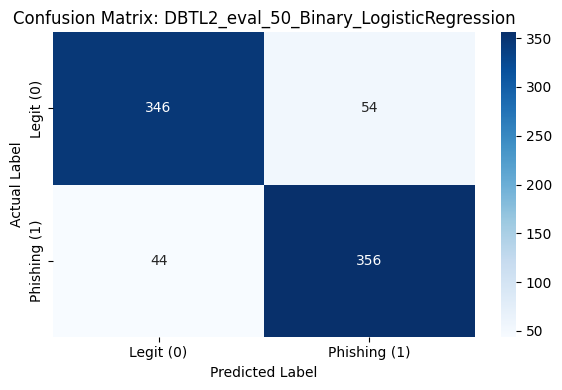

In [46]:
# --- Binary confusion matrix example ---
matrix_key = "DBTL2_eval_50_Binary_LogisticRegression"
cm = confusion_matrices[matrix_key]

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit (0)', 'Phishing (1)'],
            yticklabels=['Legit (0)', 'Phishing (1)'])
plt.title(f'Confusion Matrix: {matrix_key}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

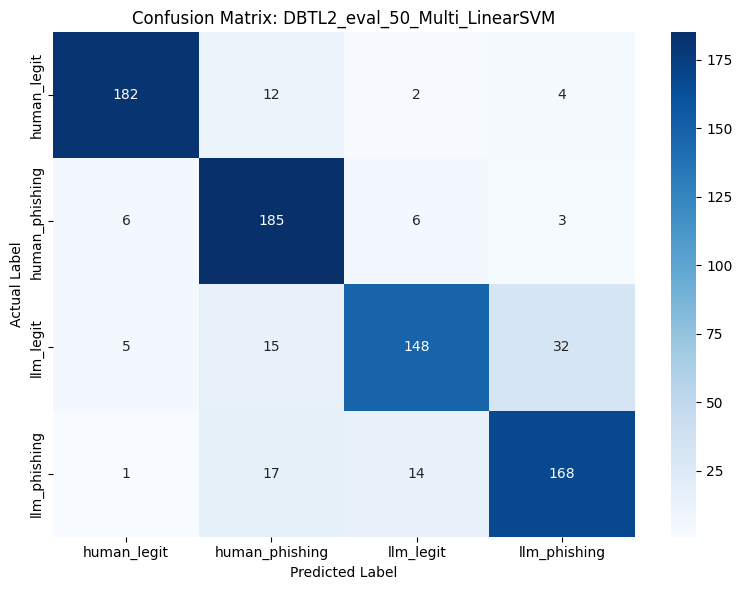

In [47]:
# --- Multi-class confusion matrix example ---
matrix_key = "DBTL2_eval_50_Multi_LinearSVM"
cm = confusion_matrices[matrix_key]

# Use the DBTL2 LabelEncoder class names for axis labels
class_names = le_dblt2.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title(f'Confusion Matrix: {matrix_key}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()